# LIME for Image Classification
This notebook implements LIME for image models entirely from scratch, with clear, step-by-step code and neat visualizations.

In [ ]:
import numpy as np
from skimage.segmentation import felzenszwalb
from skimage.color import gray2rgb
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import get_file
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as keras_image
import ipywidgets as widgets
from ipywidgets import interact, fixed
# For consistent plot display
%matplotlib inline


In [6]:
# Load the pretrained VGG16 model
model = VGG16(weights='imagenet')
print("VGG16 model loaded.")

VGG16 model loaded.


In [7]:
def segment_image(img, scale=100, sigma=0.5, min_size=50):
    if img.ndim == 2:
        img = gray2rgb(img)
    return felzenszwalb(img, scale=scale, sigma=sigma, min_size=min_size)

In [8]:
def preprocess_images(imgs):
    processed = []
    for img in imgs:
        img_pil = image.array_to_img(img)
        img_resized = img_pil.resize((224, 224))
        x = image.img_to_array(img_resized)
        processed.append(x)
    X = np.array(processed)
    return preprocess_input(X)

def predict_fn(imgs):
    X = preprocess_images(imgs)
    return model.predict(X)

In [9]:
def lime_explain(img, top_labels=5, num_samples=1000, kernel_width=0.25, random_seed=42):
    np.random.seed(random_seed)
    segments = segment_image(img)
    num_segments = np.unique(segments).shape[0]
    
    perturbations = np.random.randint(0, 2, size=(num_samples, num_segments))
    perturbations[0, :] = 1
    
    imgs = []
    for row in perturbations:
        temp = img.copy()
        for seg_val in range(num_segments):
            if row[seg_val] == 0:
                temp[segments == seg_val] = np.mean(img, axis=(0,1))
        imgs.append(temp)
    imgs = np.array(imgs)
    
    preds = predict_fn(imgs)
    explanations = {}
    distances = np.sqrt(((perturbations - 1)**2).sum(axis=1))
    weights = np.exp(-(distances**2) / (kernel_width**2))
    
    for label in np.argsort(preds[0])[-top_labels:]:
        model_ridge = Ridge(alpha=1, fit_intercept=True)
        model_ridge.fit(perturbations, preds[:, label], sample_weight=weights)
        explanations[label] = model_ridge.coef_
    
    return explanations, segments

In [10]:
def visualize_explanation(img, explanation, segments, label, top_features=5):
    coef = explanation[label]
    top_indices = np.argsort(coef)[-top_features:]
    mask = np.zeros(segments.shape, dtype=bool)
    for idx in top_indices:
        mask[segments == idx] = True
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img.astype('uint8'))
    ax[0].set_title('Original Image')
    ax[0].axis('off')
    
    ax[1].imshow(img.astype('uint8'))
    ax[1].imshow(np.dstack((mask, mask, mask)) * 255, alpha=0.5)
    ax[1].set_title(f'Top {top_features} Superpixels for Class {label}')
    ax[1].axis('off')
    plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


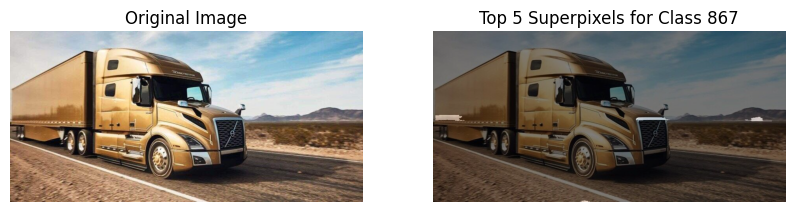

In [11]:
# Demo: Load and explain a reliable example image
img_path = get_file('truck.jpg',
                    'https://marvel-b1-cdn.bc0a.com/f00000000295579/www.tecequipment.com/app/uploads/2020/10/Volvo-Semi-Truck-900x436.jpg')
img = np.array(image.load_img(img_path))

# Run LIME
explanations, segments = lime_explain(img, top_labels=3, num_samples=500)

# Visualize for top predicted label
preds = predict_fn([img])
top_label = preds[0].argmax()
visualize_explanation(img, explanations, segments, top_label, top_features=5)


In [12]:
img_path = get_file('truck.jpg',
                    'https://marvel-b1-cdn.bc0a.com/f00000000295579/www.tecequipment.com/app/uploads/2020/10/Volvo-Semi-Truck-900x436.jpg')

img = np.array(keras_image.load_img(img_path))
segments0 = segment_image(img)
max_seg = int(segments0.max())


def plot_coef_evolution(seg_id,
                        num_samples=500,
                        repeats=10,
                        nu_min=0.0,
                        nu_max=1.0,
                        nu_steps=21):
    nus = np.linspace(nu_min, nu_max, nu_steps)
    coefs = np.zeros((repeats, len(nus)))
    for i, nu in enumerate(nus):
        for r in range(repeats):
            expl, _ = lime_explain(
                img,
                top_labels=1,
                num_samples=num_samples,
                kernel_width=nu
            )
            # get the first (and only) label’s coefficient vector
            coef_vec = expl[list(expl.keys())[0]]
            coefs[r, i] = coef_vec[seg_id]
    μ = coefs.mean(axis=0)
    σ = coefs.std(axis=0)

    plt.figure(figsize=(8, 4))
    plt.fill_between(nus, μ - σ, μ + σ, alpha=0.3)
    plt.plot(nus, μ, '-b', linewidth=2)
    plt.axvline(0.25, color='r', linewidth=1.5)
    plt.hlines(0, nus.min(), nus.max(), linestyles='dashed')
    plt.xlabel('ν (kernel_width)')
    plt.ylabel(f'β̂_{{{seg_id}}}')
    plt.title(f'Evolution of β̂_{{{seg_id}}} as a function of ν')
    plt.show()

interact(
    plot_coef_evolution,
    seg_id=widgets.IntSlider(
        min=0, max=max_seg, step=1, value=13, description='Segment ID'
    ),
    num_samples=widgets.IntSlider(
        min=100, max=2000, step=100, value=500, description='Samples'
    ),
    repeats=widgets.IntSlider(
        min=1, max=50, step=1, value=10, description='Repetitions'
    ),
    nu_min=fixed(0.0),
    nu_max=fixed(1.0),
    nu_steps=widgets.IntSlider(
        min=5, max=100, step=1, value=21, description='ν Steps'
    )
)



interactive(children=(IntSlider(value=13, description='Segment ID', max=872), IntSlider(value=500, description…

<function __main__.plot_coef_evolution(seg_id, num_samples=500, repeats=10, nu_min=0.0, nu_max=1.0, nu_steps=21)>